# Dam Break

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import wiener, butter, freqs, convolve, freqz, convolve2d
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq, fft2, ifft2
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.pre_processing import gaussian, gaussian_f, convolve_f, convolve_f2D, smoothen
from smooth_POD_ROM.post_processing import post_process
from smooth_POD_ROM.reduced_order_model import train_ROM, L2_error, zielfunktion
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from datetime import datetime
from scipy.optimize import minimize
#import nlopt

In [2]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/DamBreak2/"
wdth = hght = 0.584
threshol = False
ts = 0.25
n_x = n_y = 344
c = 0.6
truncate = 8
num_iter = 10
padding = 0.1
brute_force_search = False
optimize_sigma = True

dx = dy = (wdth+2*padding)/(n_x-1)
sigma = 0.01 # 8.75 * dx

shape = (n_x, n_y)
print(dx, sigma/dx)

0.002285714285714286 4.375


In [3]:
X_train_msh = np.load(pth+"t{:.2f}_X_train.npy".format(ts))
X_test_msh = np.load(pth+"t{:.2f}_X_test.npy".format(ts))
X_val_msh = np.load(pth+"t{:.2f}_X_val.npy".format(ts))
n_h = len(X_train_msh)
mu_train2 = np.load(pth+"t{:.2f}_mu_train.npy".format(ts))
mu_test2 = np.load(pth+"t{:.2f}_mu_test.npy".format(ts))
mu_val2 = np.load(pth+"t{:.2f}_mu_val.npy".format(ts))

mu_train = np.log2(mu_train2/10)
mu_test = np.log2(mu_test2/10)
mu_val = np.log2(mu_val2/10)

points = np.load(pth+"points.npy")

nu_grid = np.arange(0, 7, .5)#[::2]  # 10*2**np.arange(0, 10, 1)
rho_grid = np.arange(2, 6, .25)#[::4]  # 10*2**np.arange(0, 8, 1)
mu_train = mu_train.reshape(14, 16, 2)#[::2, ::4, :]
X_train_msh = X_train_msh.reshape(n_h, 14, 16)#[:, ::2, ::4]
n_train = mu_train.size // 2
print(mu_train[:, :, 0])
print(mu_train[:, :, 1])
print()
mu_train = mu_train.reshape(n_train, 2)
X_train_msh = X_train_msh.reshape(n_h, n_train)


test_inside = ((nu_grid[0] <= mu_test[:, 0]) & (mu_test[:, 0] <= nu_grid[-1]) & 
               (rho_grid[0] <= mu_test[:, 1]) & (mu_test[:, 1] <= rho_grid[-1]))
print(test_inside)
mu_test = mu_test[test_inside, :]
X_test_msh = X_test_msh[:, test_inside]
print(X_test_msh.shape, mu_test.shape)

print(points.shape)
print(X_train_msh.shape, X_test_msh.shape, X_val_msh.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]
 [1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]
 [2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2. ]
 [2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5]
 [3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3. ]
 [3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5 3.5]
 [4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4. ]
 [4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5 4.5]
 [5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5. ]
 [5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5 5.5]
 [6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6. ]
 [6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5 6.5]]
[[2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25 4.5  4.75

In [4]:
x = np.linspace(0-padding, wdth+padding, n_x, endpoint=True)
y = np.linspace(0-padding, hght+padding, n_y, endpoint=True)
dx, dy = x[1]-x[0], y[1]-y[0]
print(dx, x[-1], x[0])
X, Y = np.meshgrid(x, y, indexing="ij")
is_outside = (X < 0.0) | (wdth < X) | (Y < 0.0) | (hght < Y)
is_wall = ((0.292 <= X) & (X <= 0.316) & (Y <= 0.048))

def remove_wall(snapshots_flat, is_wall, is_outside, threshol):
    snapshots_flat = snapshots_flat.copy()
    for j in range(snapshots_flat.shape[1]):
        snapshots_flat[:, j][is_outside.ravel()] = 0.5
        snapshots_flat[:, j][is_wall.ravel()] = 0.5
    if threshol:
        snapshots_flat[snapshots_flat>0.5] = 1
        snapshots_flat[snapshots_flat<0.5] = 0.0
    return snapshots_flat


0.00228571428571428 0.6839999999999999 -0.1


In [5]:
X_train = np.empty((n_x*n_y, X_train_msh.shape[1]))
X_test = np.empty((n_x*n_y, X_test_msh.shape[1]))
X_val = np.empty((n_x*n_y, X_val_msh.shape[1]))


for X_set_grd, X_set_msh in zip([X_train, X_test, X_val],
                                [X_train_msh, X_test_msh, X_val_msh]):
    for j in range(X_set_msh.shape[1]):
        gridded = griddata(points[:, :2], X_set_msh[:, j], (X, Y), method="nearest").ravel()
        if threshol:
            gridded[gridded>0.5] = 1
            gridded[gridded<0.5] = 0.0
        #gridded[is_wall] = 0.5
        X_set_grd[:, j] = gridded
        # do not do this!
        #X_set_s[:, j] = gaussian_filter(gridded, sigma=sigma/dx, truncate=truncate).ravel()
gridded_shape = gridded.shape
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()
X_val_orig = X_val.copy()

[ 10.          14.14213562  20.          28.28427125  40.
  56.56854249  80.         113.13708499 160.         226.27416998
 320.         452.54833996 640.         905.09667992]
[ 40.          47.5682846   56.56854249  67.27171322  80.
  95.1365692  113.13708499 134.54342644 160.         190.2731384
 226.27416998 269.08685288 320.         380.5462768  452.54833996
 538.17370576]
224


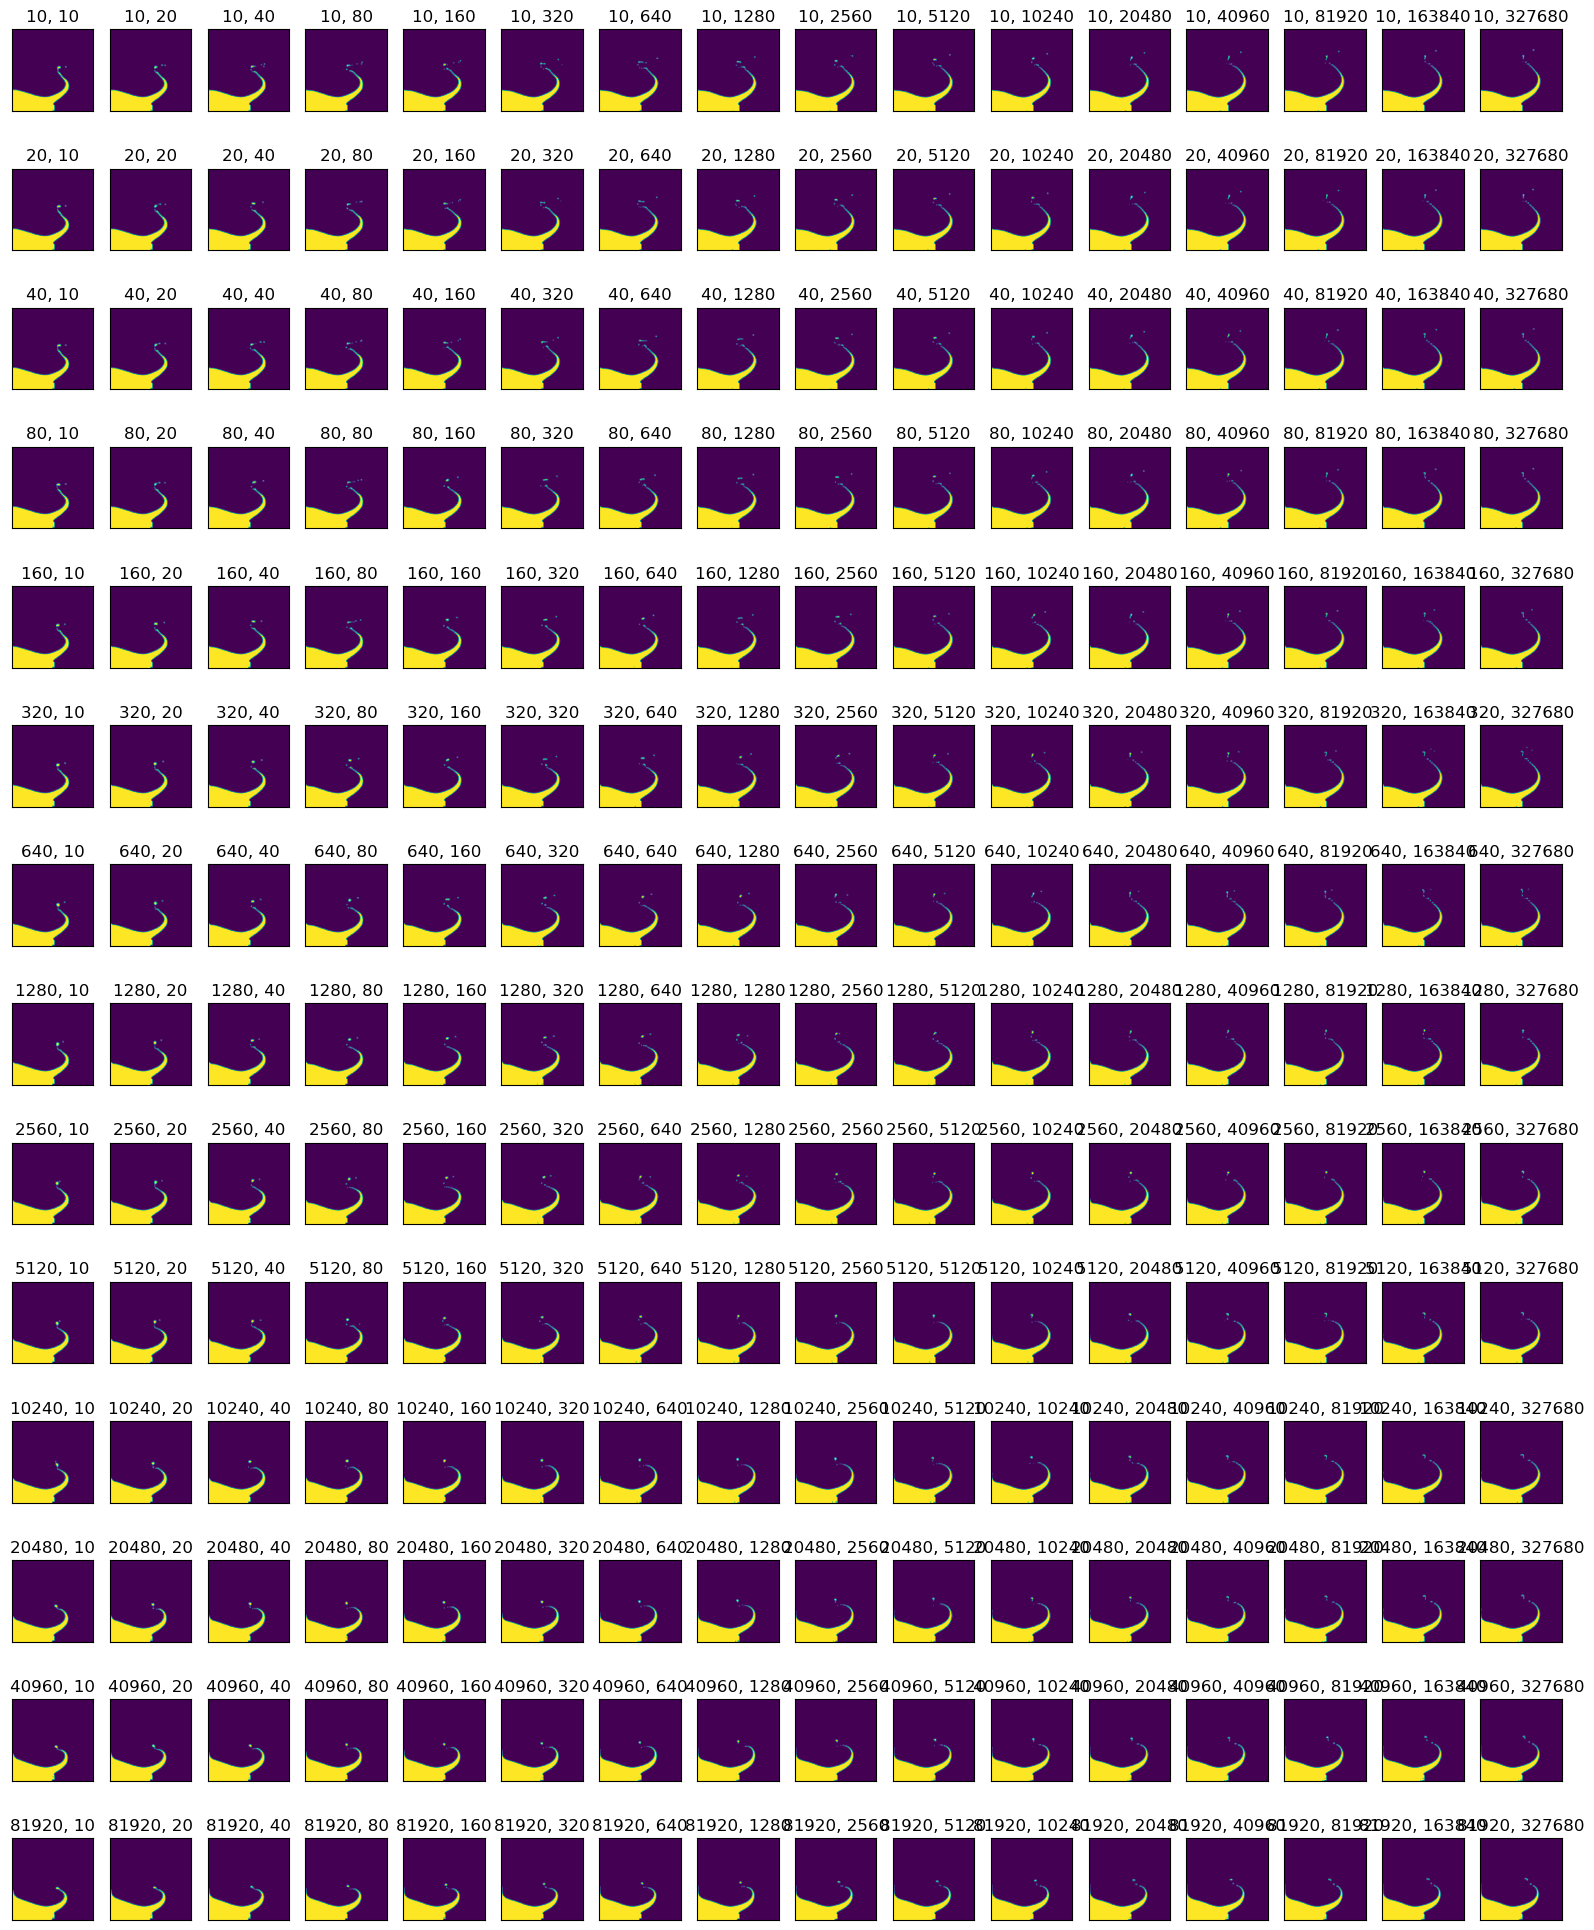

In [6]:
nu_all = 10*2**np.arange(0, 7, .5)  # 10*2**np.arange(0, 10, 1)
rho_all = 10*2**np.arange(2, 6, .25)  # 10*2**np.arange(0, 8, 1)
print(nu_all)
print(rho_all)
print(len(nu_all)*len(rho_all))

fig, axs = plt.subplots(len(nu_all), len(rho_all), figsize=(20, 25))
for j, m in enumerate(mu_train):
    a, b = int(m[0]*2), int(m[1]*4-8)
    axs[a][b].imshow(X_train[:, j].reshape(shape).T[43:-43, 43:-43], origin="lower")
    axs[a][b].set_title(str(10*2**a)+", "+str(10*2**b))
    axs[a][b].set_xticks([])
    axs[a][b].set_yticks([])
plt.show()

# Standard ROM

In [7]:
print(np.min(mu_train, axis=0), np.max(mu_train, axis=0))
print(np.min(mu_test, axis=0), np.max(mu_test, axis=0))


[0. 2.] [6.5  5.75]
[0.11144536 2.09786021] [5.33176683 5.73866787]


0.014363556609882634


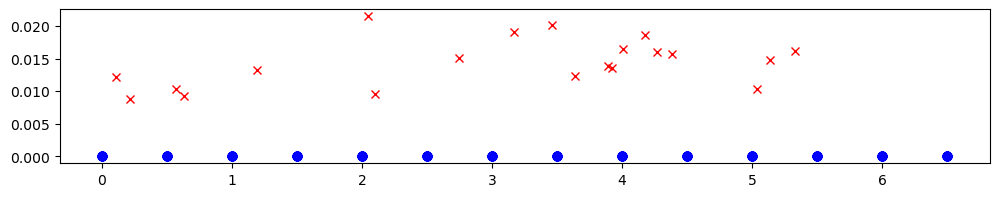

In [8]:
X_test_nw = remove_wall(X_test, is_wall, is_outside, threshol)

standard_rom = train_ROM(mu_train, X_train, rank=len(mu_train))
X_test_ROM = standard_rom.predict(mu_test).T
X_test_ROM_nw = remove_wall(X_test_ROM, is_wall, is_outside, threshol)
e_ROM = L2_error(X_test_ROM_nw, X_test_nw)
mean_eROM = np.mean(e_ROM)

plt.figure(figsize=(12, 2))
plt.plot(mu_test[:,  0], e_ROM, "rx")
plt.plot(mu_train[:,  0], np.zeros_like(mu_train), "bo")
print(mean_eROM)

# regularized ROM

In [9]:
def plot_dam_snapshot(ax, u, ue, X, Y, dx, dy):
    u = u.copy()
    ue = ue.copy()
    cmap = plt.cm.viridis_r
    #cmap.set_under('C3')
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dy/2, np.max(y)+dy/2)
    cs = ax.imshow(u.T, origin="lower", interpolation="nearest", extent=extent, cmap=cmap, vmin=0, vmax=1)
    ax.contour(X, Y, ue, levels=[0.5], linewidths=[1], colors=["r"])
    e = L2_error(u.ravel(), ue.ravel())
    ax.set_title("$||u-u_e||={:.6f}$".format(e))
    return cs

In [10]:
X_train_orig = X_train.copy()
X_test_orig = X_test.copy()

[0.21453517 5.10073844]


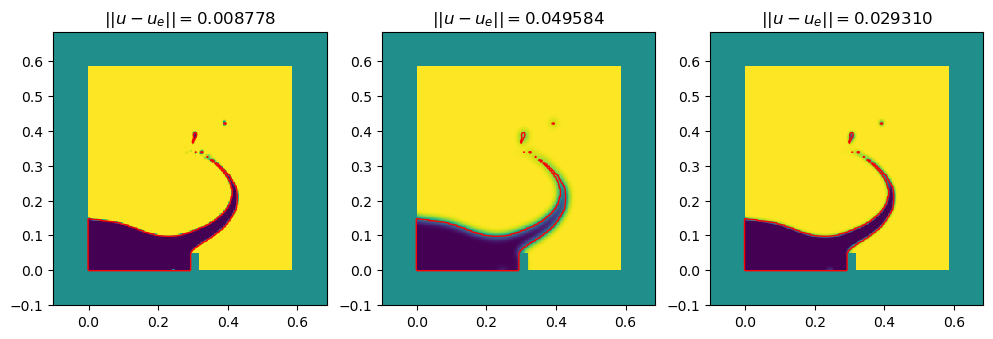

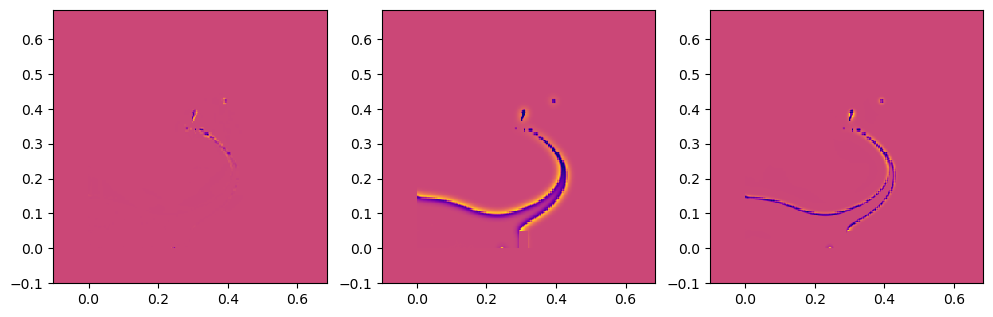

[2.09797817 5.20380098]


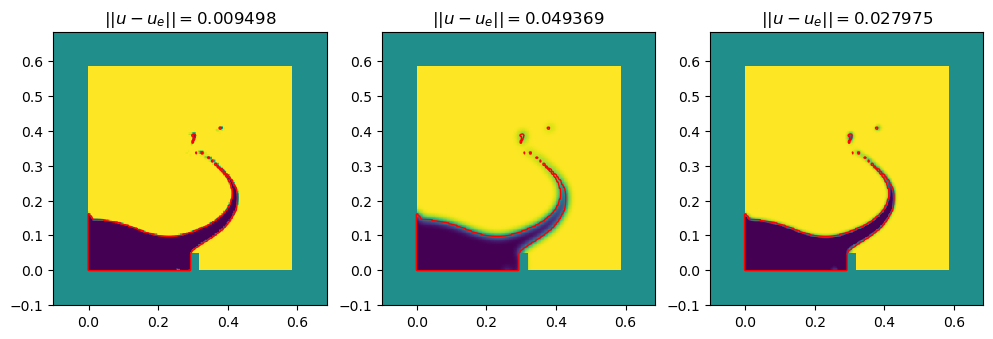

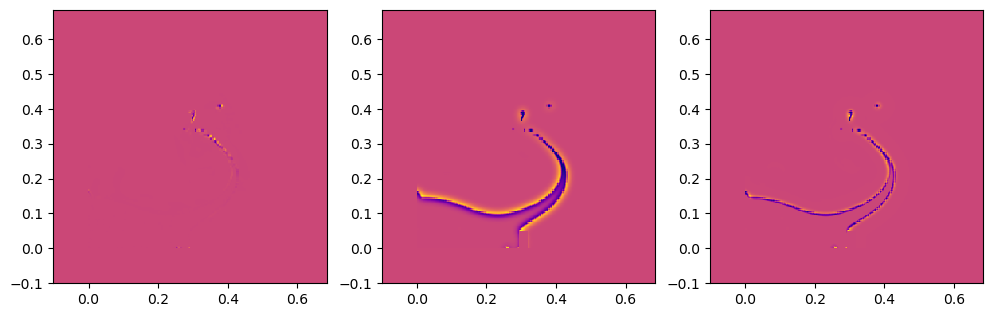

[3.16713791 3.88884064]


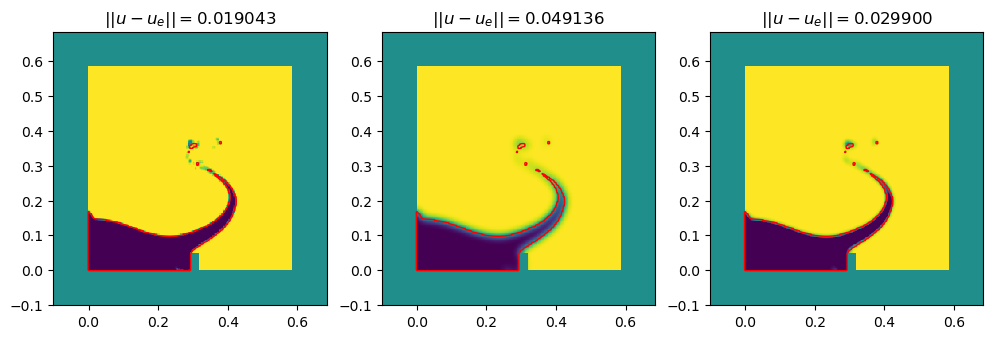

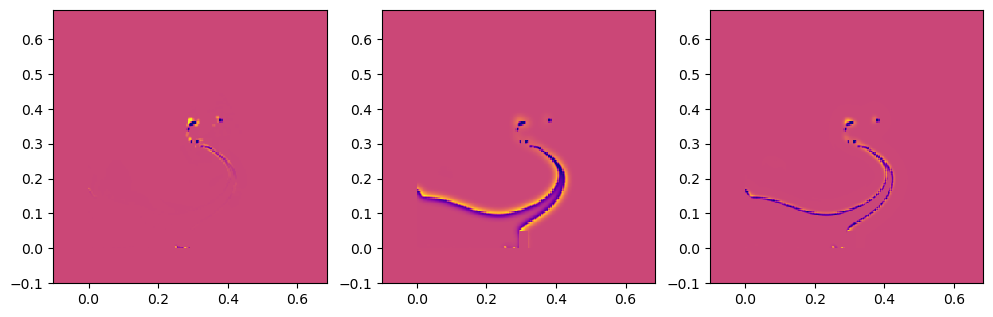

[3.46018031 3.40249435]


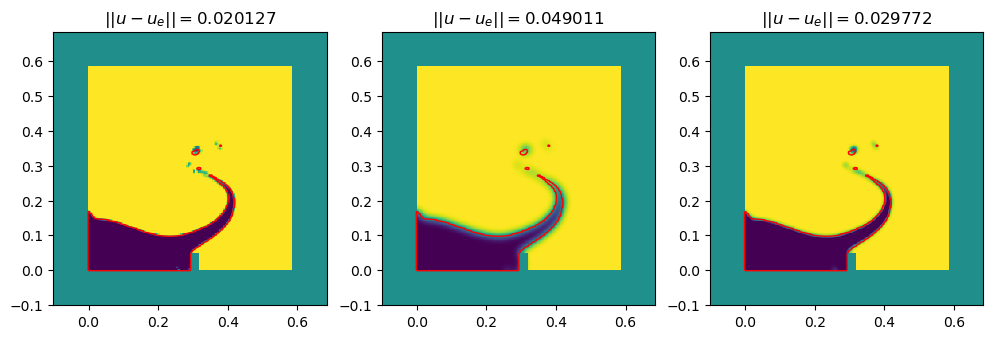

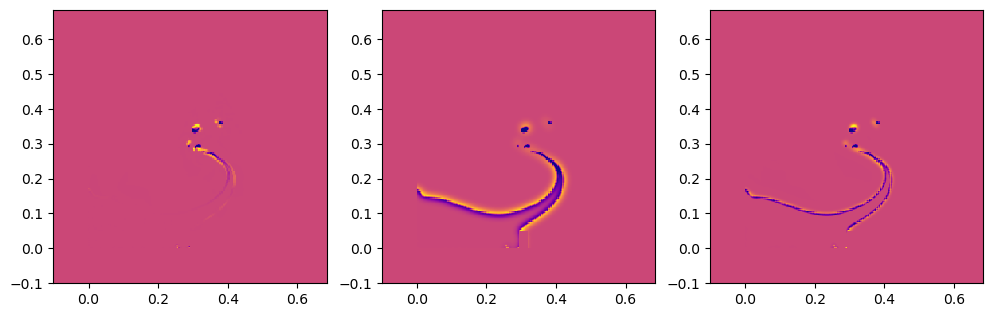

[4.00593618 2.36824592]


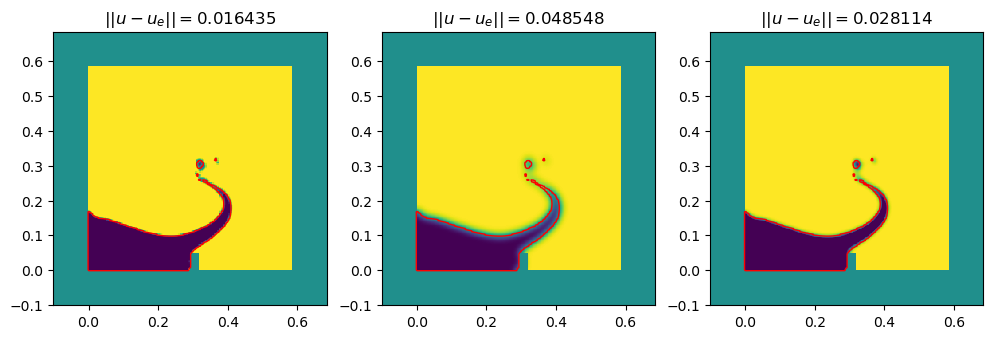

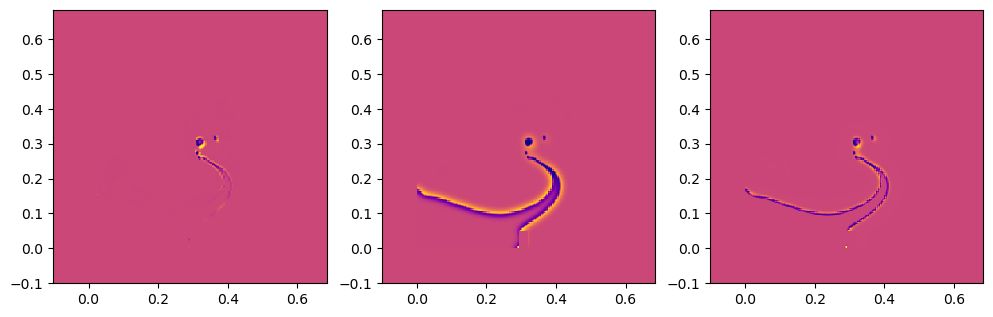

[3.9199607  3.15311949]


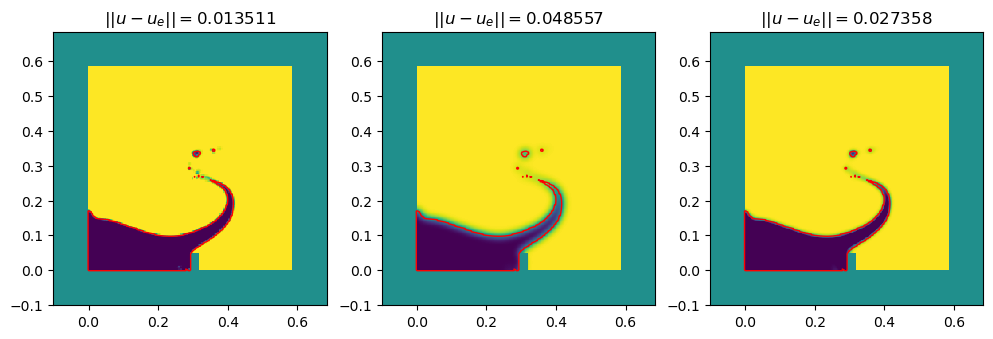

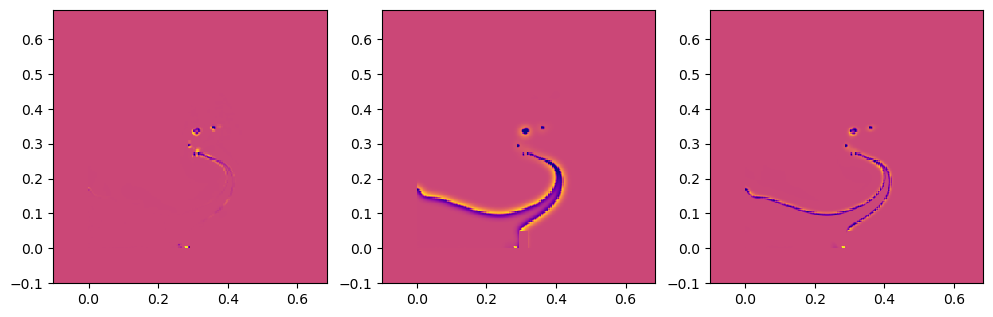

[2.04867214 3.20821914]


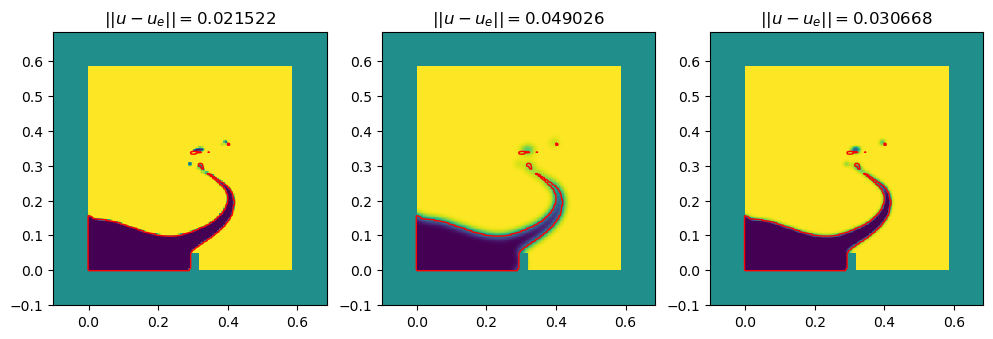

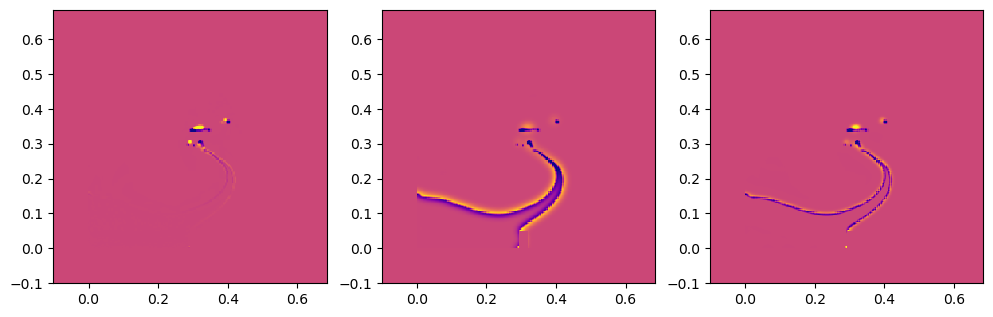

[4.38253861 3.04285792]


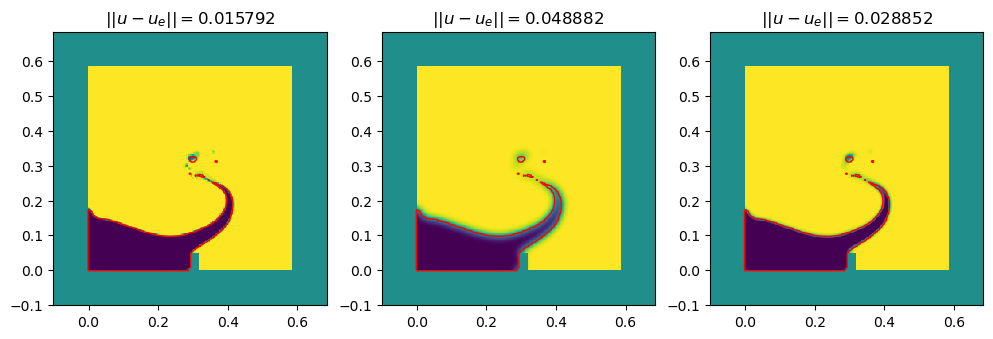

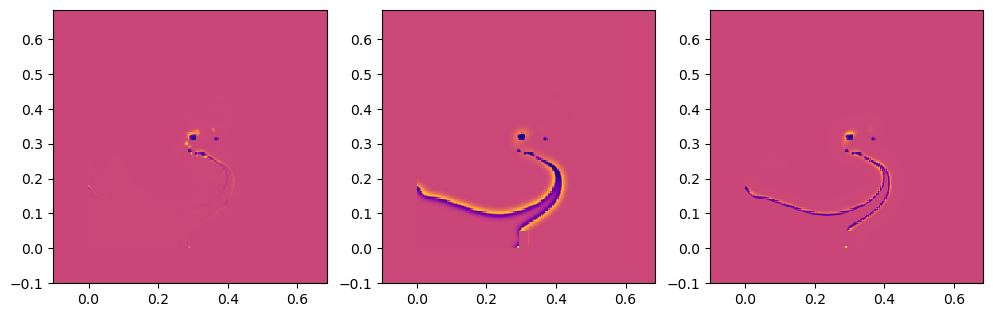

[0.56952998 5.48270149]


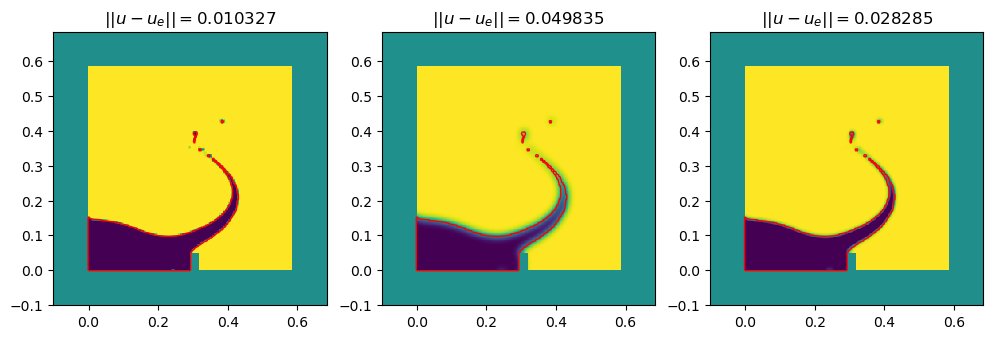

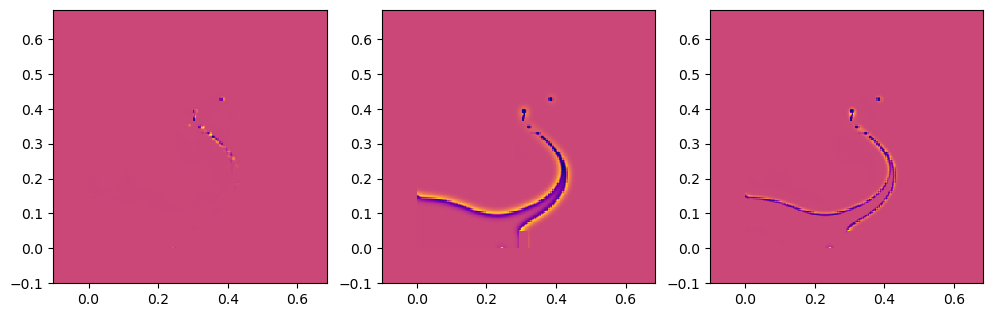

[5.13790349 4.53006949]


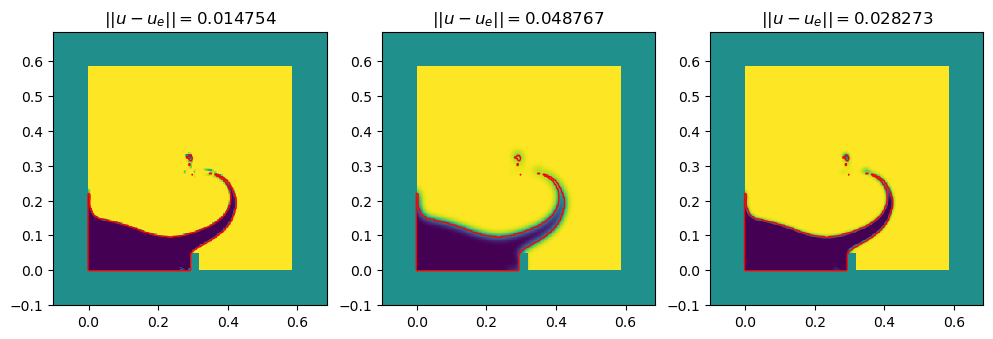

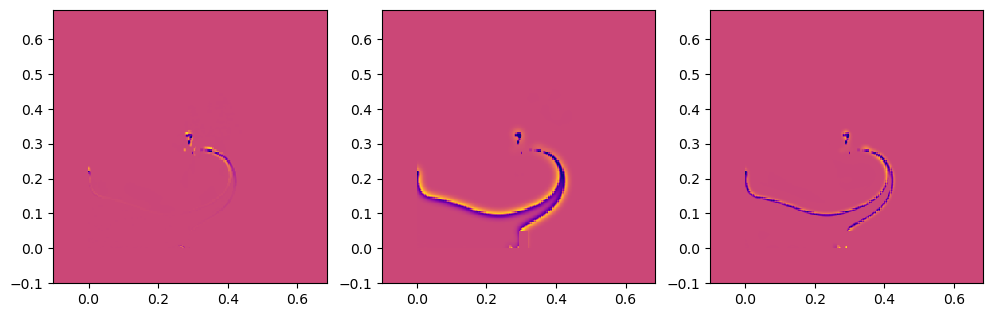

[3.63587974 4.77496676]


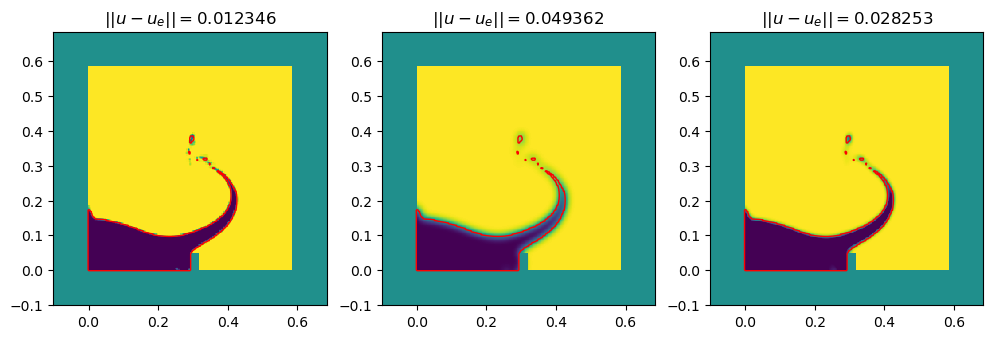

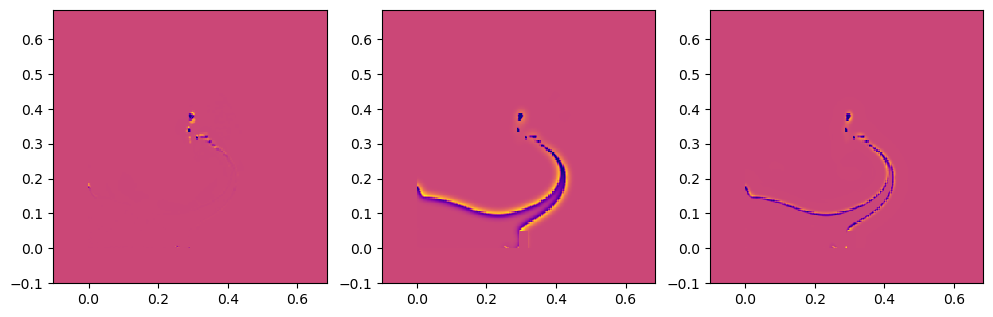

[1.1954358  4.81694728]


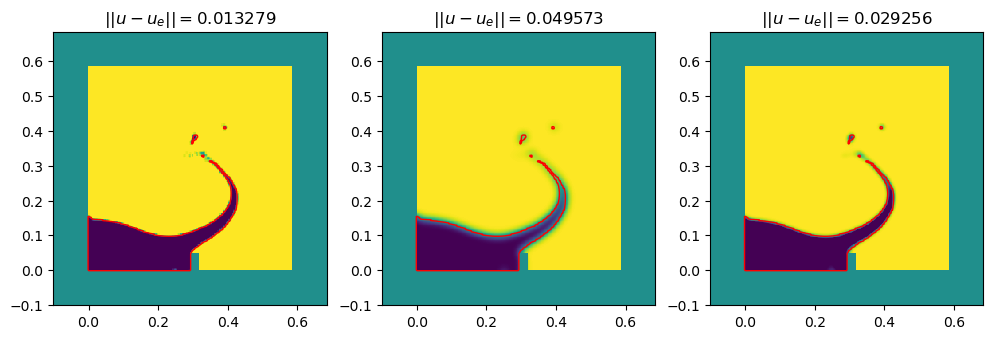

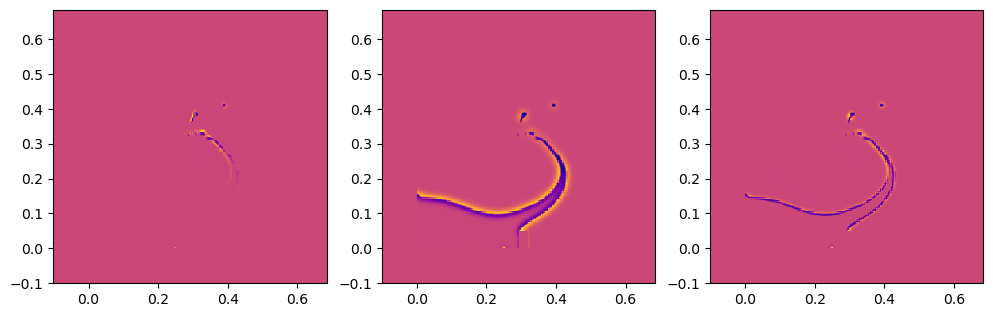

[4.17184811 5.24003416]


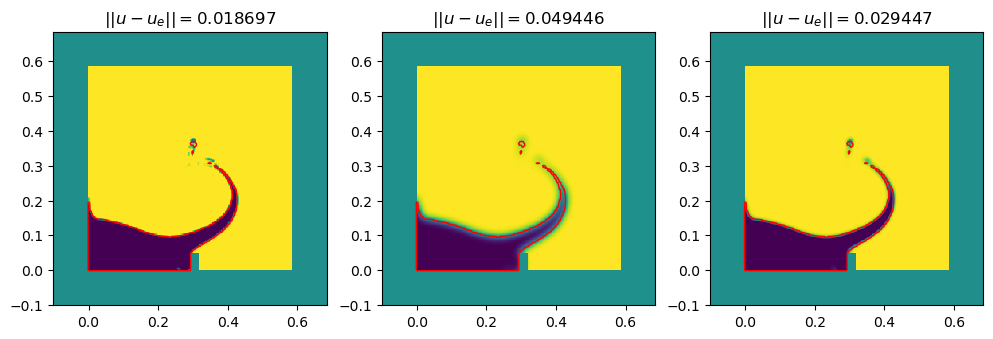

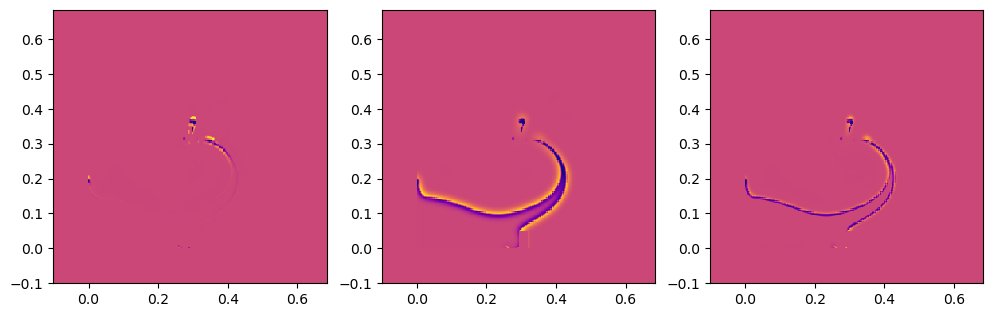

[5.03996437 2.54908015]


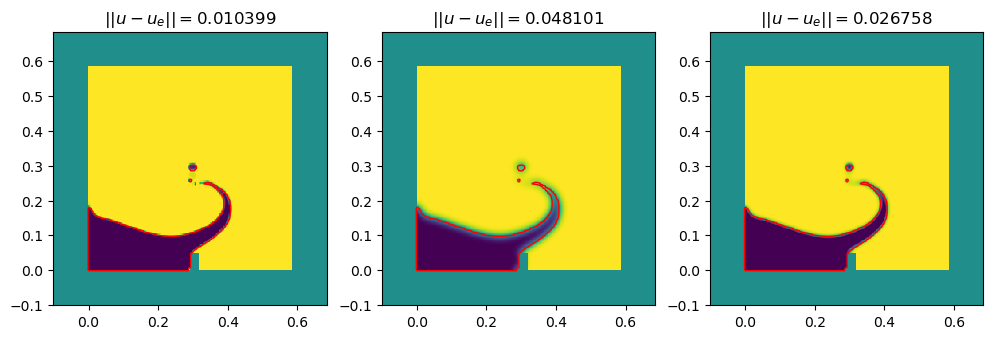

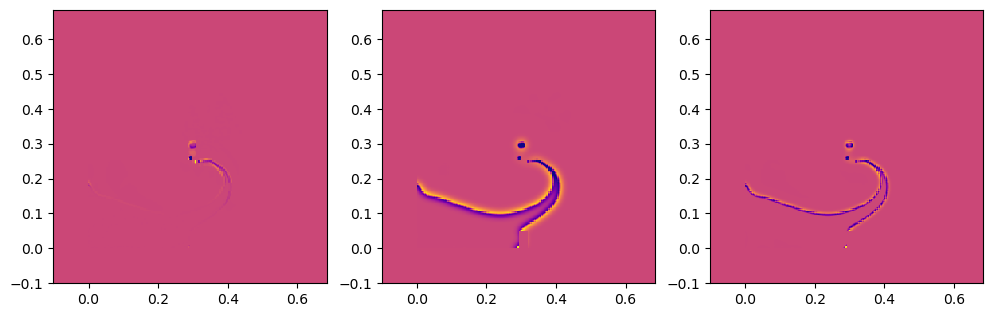

[3.89396402 2.09786021]


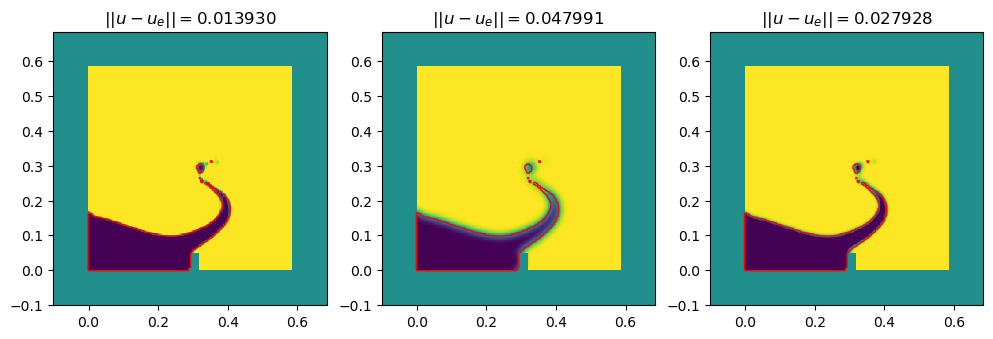

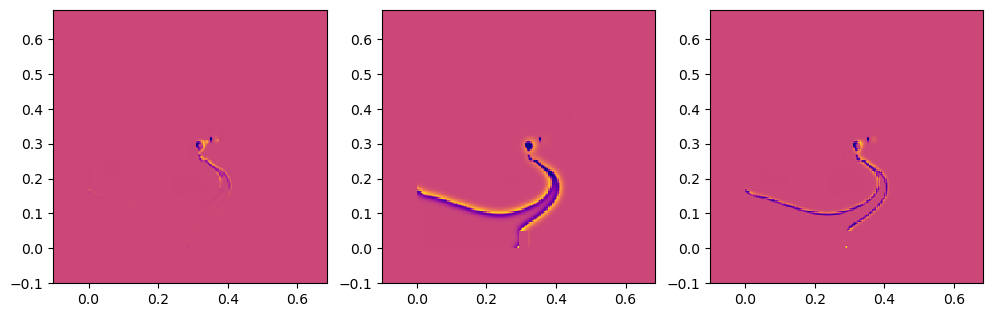

[4.26456195 5.73866787]


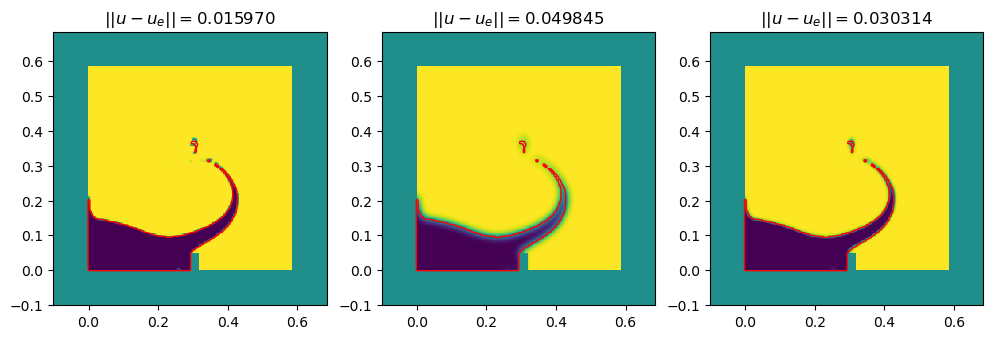

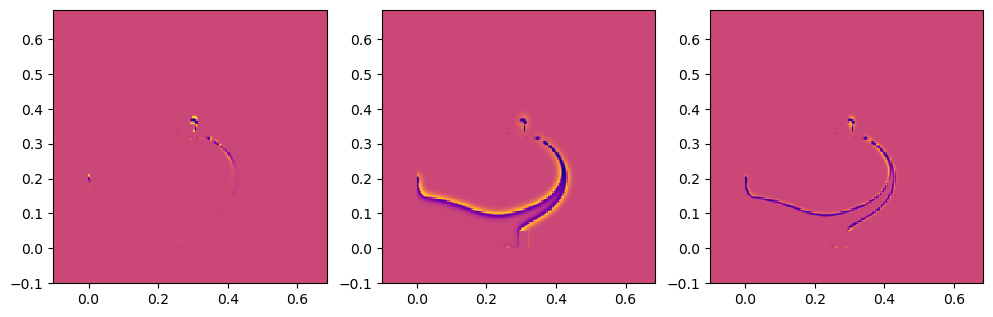

[0.11144536 4.82221109]


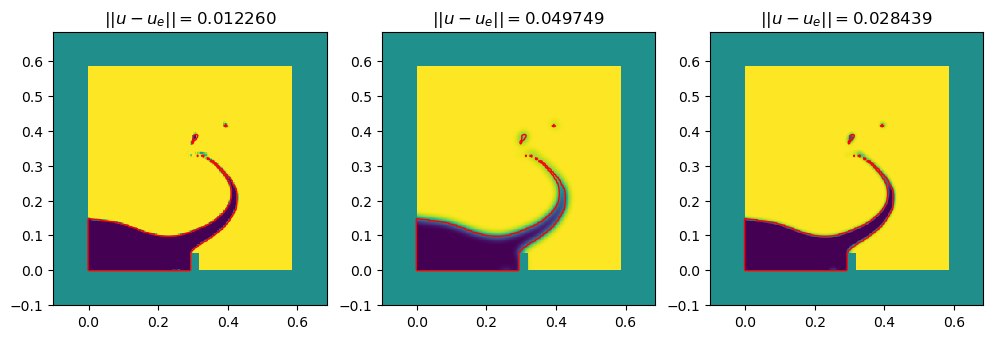

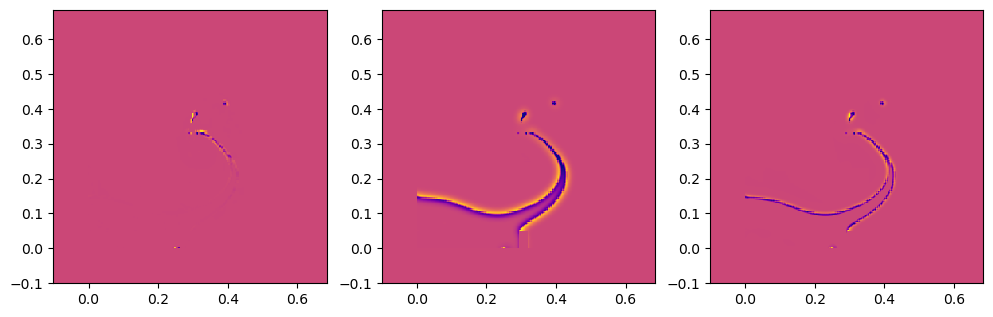

[5.33176683 3.42224915]


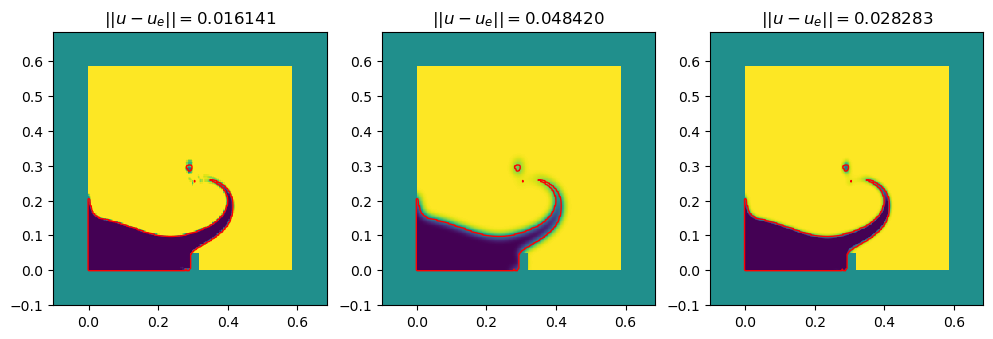

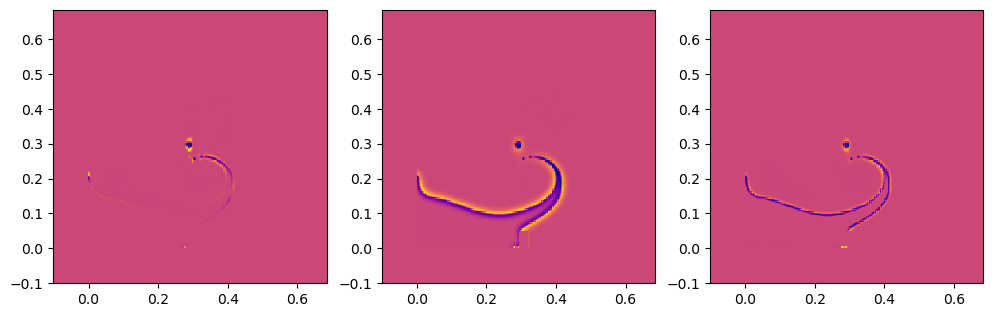

[2.74925321 3.09886923]


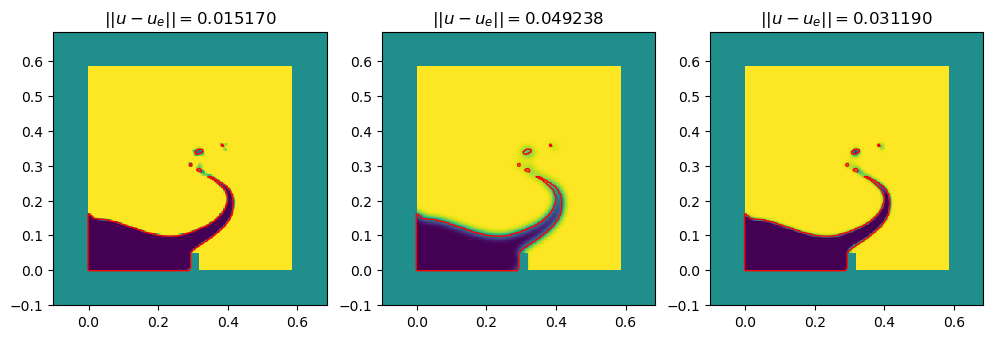

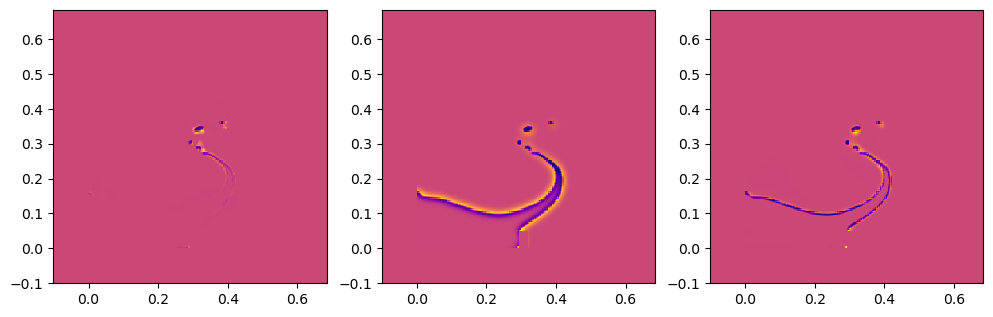

[0.6345468  4.70163278]


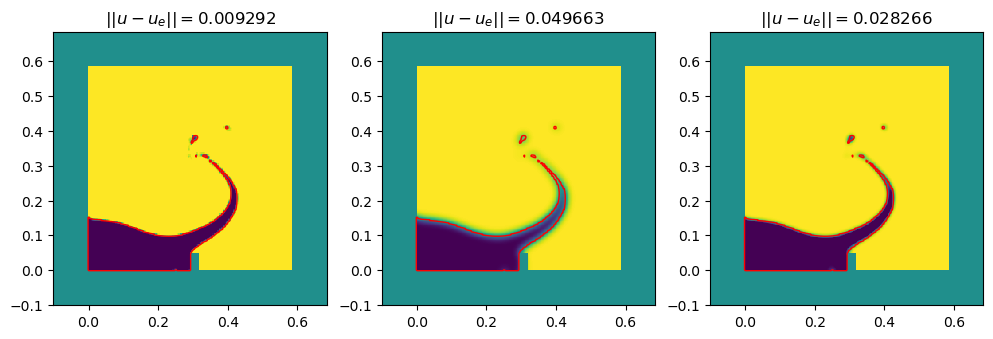

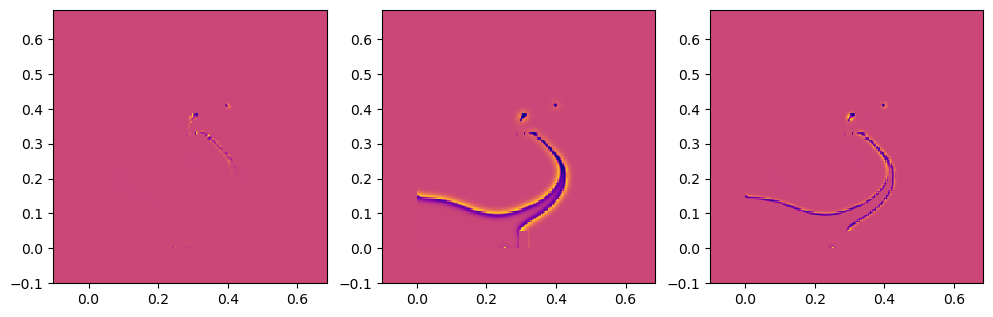

ROM error 0.014363556609882634
sROM error 0.0491051332734058
sROMs error 0.02883214197827543


In [11]:
# if threshol:
#     X_train = X_train_orig.copy()
#     X_train[X_train>.5] = 1
#     X_train[X_train<.5] = 0
    
#     X_test = X_test_orig.copy()
#     X_test[X_test>.5] = 1
#     X_test[X_test<.5] = 0

standard_rom = train_ROM(mu_train, X_train, rank=len(mu_train))
X_test_ROM = standard_rom.predict(mu_test).T
X_test_ROM_nw = remove_wall(X_test_ROM, is_wall, is_outside, threshol)
e_ROM = L2_error(X_test_ROM_nw, X_test_nw)
mean_eROM = np.mean(e_ROM)
    
X_train_s = smoothen(X_train, sigma/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=len(mu_train))
X_test_sROM = smooth_rom.predict(mu_test).T
X_test_sROM_nw = remove_wall(X_test_sROM, is_wall, is_outside, threshol)
e_sROM = L2_error(X_test_sROM_nw, X_test_nw)
#print(e_sROM)
X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape, clip=True)
X_test_sROMs_nw = remove_wall(X_test_sROMs, is_wall, is_outside, threshol)
e_sROMs = L2_error(X_test_sROMs_nw, X_test_nw)
mean_sROMs = np.mean(e_sROMs)

for j in range(len(mu_test)):
    print(mu_test[j])
    ue = X_test_nw[:, j].reshape(shape)
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    plot_dam_snapshot(axs[0], X_test_ROM_nw[:, j].reshape(shape), ue, X, Y, dx, dy)
    plot_dam_snapshot(axs[1], X_test_sROM_nw[:, j].reshape(shape), ue, X, Y, dx, dy)
    plot_dam_snapshot(axs[2], X_test_sROMs_nw[:, j].reshape(shape), ue, X, Y, dx, dy)
    plt.show()
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dy/2, np.max(y)+dy/2)
    axs[0].imshow((X_test_ROM_nw[:, j].reshape(shape)-ue).T, origin="lower", interpolation="nearest",
                  extent=extent, cmap=cmap, vmin=-.5, vmax=.5)
    axs[1].imshow((X_test_sROM_nw[:, j].reshape(shape)-ue).T, origin="lower", interpolation="nearest",
                  extent=extent, cmap=cmap, vmin=-.5, vmax=.5)
    axs[2].imshow((X_test_sROMs_nw[:, j].reshape(shape)-ue).T, origin="lower", interpolation="nearest",
                  extent=extent, cmap=cmap, vmin=-.5, vmax=.5)
    plt.show()
    
print("ROM error", np.mean(e_ROM))
print("sROM error", np.mean(e_sROM))
print("sROMs error", np.mean(e_sROMs))

In [12]:
print("ROM error", np.mean(e_ROM))
print("sROM error", np.mean(e_sROM))
print("sigma, c, error, decrese in error (smaller is better)")
if optimize_sigma:
#     def zielfunktion_old(params, grad=None):
#         # bounds=[(0, 5*dx), (-1, 2)] = [(0, 1), (0, 1)]
#         # sigma, c = params[0]*5*dx, params[1]*3-1
#         sigma, c = params[0], params[1]
#         X_train_s = smoothen(X_train, sigma/dx, shape)
#         smooth_rom = train_ROM(mu_train, X_train_s, rank=len(mu_train))
#         X_test_sROM = smooth_rom.predict(mu_test).T
#         X_test_sROM_nw = remove_wall(X_test_sROM, is_wall, is_outside, threshol)
#         e_sROM = L2_error(X_test_sROM_nw, X_test_nw)
#         #print(e_sROM)
#         X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape, clip=True)
#         X_test_sROMs_nw = remove_wall(X_test_sROMs, is_wall, is_outside, threshol)
#         e_sROMs = L2_error(X_test_sROMs_nw, X_test_nw)
#         mean_sROMs = np.mean(e_sROMs)

#         print("{:.6f}, {:.4f}, {:.8f}, {:.1f} %".format(sigma, c, mean_sROMs, 100*mean_sROMs/np.mean(e_ROM)-100))
#         return mean_sROMs
    target_fun =  lambda x0: zielfunktion(x0, x, mu_train, X_train, mu_test, X_test, rank=len(mu_train), shape=shape, num_iter=num_iter)[0]
    x0 = np.array([2.5*dx, 0.5])
    #x0 = np.array([0.45*dx, 0.5])
    x0 = np.array([1.12*dx, 1.17])
    x0 = np.array([8.75*dx, 1.0])
    res = minimize(target_fun, x0, method='nelder-mead', bounds=[(0, 10*dx), (-2, 2)], options={'disp': True, "fatol": 1e-5})
    #res = minimize(zielfunktion, x0, method='BFGS', options={'disp': True, 'eps': np.array([0.005, 0.005])})


    # opt = nlopt.opt("DIRECT", 2)
    # opt.set_min_objective(zielfunktion)
    # opt.set_lower_bounds([0, -1])
    # opt.set_upper_bounds([5*dx, 2])
    # opt.set_ftol_rel(1e-6)
    # xopt = opt.optimize(x)
    # res["x"] = xopt

    sigma, c = res["x"]
    print(sigma/dx, c)

ROM error 0.014363556609882634
sROM error 0.0491051332734058
sigma, c, error, decrese in error (smaller is better)
0.020000, 1.0000, 0.08003428, 328.0676 %
0.021000, 1.0000, 0.08230047, 340.1885 %
0.020000, 1.0500, 0.08060009, 331.0939 %
0.019000, 1.0500, 0.07827354, 318.6502 %
0.018000, 1.0750, 0.07616625, 307.3793 %
0.018000, 1.0250, 0.07561033, 304.4059 %
0.017000, 1.0125, 0.07302906, 290.5998 %
0.015000, 1.0875, 0.06878723, 267.9122 %
0.012500, 1.1312, 0.06254160, 234.5071 %
0.011500, 1.0687, 0.05919596, 216.6127 %
0.008250, 1.0656, 0.04976943, 166.1944 %
0.003750, 1.1844, 0.03626300, 93.9546 %
0.000000, 1.2703, 0.01869664, -0.0000 %
0.000000, 1.2047, 0.01869664, -0.0000 %
0.000000, 1.4094, 0.01869664, -0.0000 %
0.000000, 1.3234, 0.01869664, -0.0000 %
0.000000, 1.1516, 0.01869664, -0.0000 %
0.000000, 1.2805, 0.01869664, -0.0000 %
0.000000, 1.2375, 0.01869664, -0.0000 %
0.000000, 1.2969, 0.01869664, -0.0000 %
0.000000, 1.2109, 0.01869664, -0.0000 %
0.000000, 1.2754, 0.01869664, -0.0

In [13]:
if brute_force_search:
    sigmas = np.arange(0, 2, 0.2)*dx
    cs = np.arange(0.0, 2, 0.2)
    print(len(sigmas), len(cs), len(sigmas)*len(cs), "evaluations")
    error_matrix_sROM = np.empty((len(sigmas), len(mu_test)))
    error_matrix_sROMs = np.empty((len(sigmas), len(cs), len(mu_test)))
    e_min = mean_eROM
    for i, sigma in enumerate(sigmas):
        X_train_s = smoothen(X_train, sigma/dx, shape)
        smooth_rom = train_ROM(mu_train, X_train_s, rank=len(mu_train))
        X_test_sROM = smooth_rom.predict(mu_test).T
        X_test_sROM_nw = remove_wall(X_test_sROM, is_wall, is_outside, threshol)
        e_sROM = L2_error(X_test_sROM_nw, X_test_nw)
        error_matrix_sROM[i] = e_sROM
        for j, c in enumerate(cs):
            X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape=shape, clip=True)
            X_test_sROMs_nw = remove_wall(X_test_sROMs, is_wall, is_outside, threshol)
            e_sROMs = L2_error(X_test_sROMs_nw, X_test_nw)
            error_matrix_sROMs[i, j] = e_sROMs
            mean_sROMs = np.mean(e_sROMs)
            print(i*len(cs)+j, i, j, sigmas[i]/dx, cs[j], mean_sROMs)
    #         if np.mean(e_sROMs) < mean_eROM:
    #             print(sigma, c, np.mean(e_ROM), np.mean(e_sROM), np.mean(e_sROMs))

    #         plt.imshow(X_test_ROM[:, 0].reshape(shape))
    #         plt.show()
    #         plt.imshow(X_test_sROM[:, 0].reshape(shape))
    #         plt.show()
    #         plt.imshow(X_test_sROMs[:, 0].reshape(shape))
    #         plt.show()
    np.mean(e_sROMs)

    print(c, np.mean(e_sROMs))

In [14]:
if brute_force_search:
    mean_eROM = np.mean(e_ROM)
    mean_esROM = np.mean(error_matrix_sROM, axis=-1)
    mean_esROMs = np.mean(error_matrix_sROMs, axis=-1)

    print(mean_eROM)
    print(np.min(mean_esROM), np.max(mean_esROM))
    print(np.min(mean_esROMs), np.max(mean_esROMs))
    print(np.min(mean_esROMs)/mean_eROM)
    fig, ax = plt.subplots()
    dc = cs[1]-cs[0]
    ds = sigmas[1]-sigmas[0]
    ext = (cs[0]-dc/2, cs[-1]+dc/2, (sigmas[0]-ds/2)/dx, (sigmas[-1]+ds/2)/dx)
    ax.imshow(mean_esROMs, interpolation="nearest", origin="lower", vmax=mean_eROM*1.0, extent=ext)
    np.save(pth+"mean_esROMs.npy", mean_esROMs)
    ax.set_xticks(cs)
    ax.set_yticks(sigmas/dx)
    ax.set_aspect("auto")
    plt.show()
    print(np.min(mean_esROMs[0, :]))
    print(np.min(mean_esROMs[-1, :]))
    i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
    print(i, j, sigmas[i]/dx, cs[j])
    sigma, c = sigmas[i], cs[j]

X_train


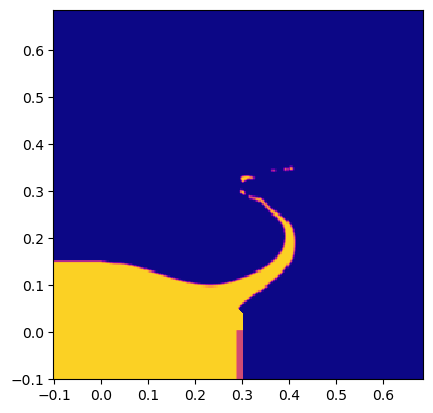

X_train_s


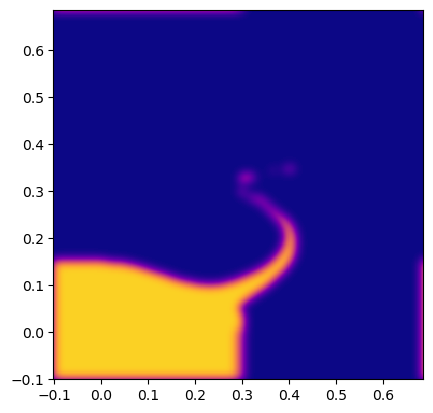

X_test


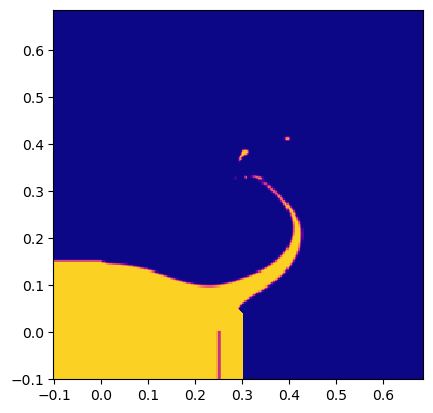

X_test_nw


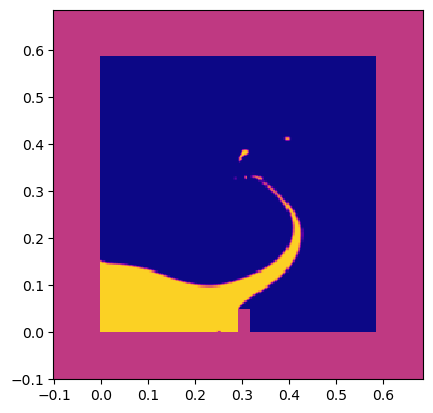

X_test_ROM


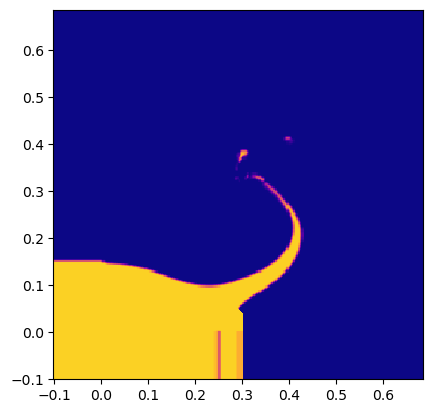

X_test_ROM_nw


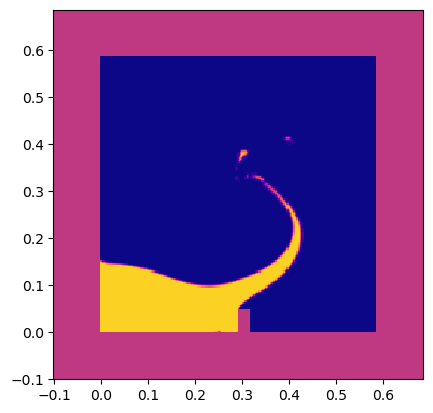

X_test_sROM


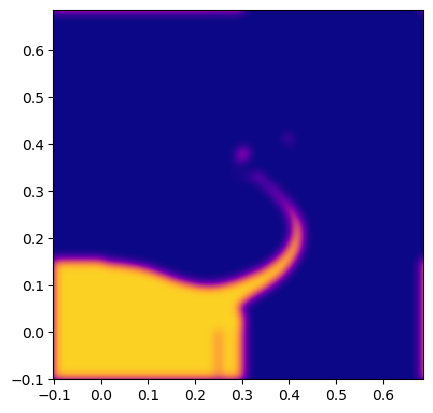

X_test_sROM_nw


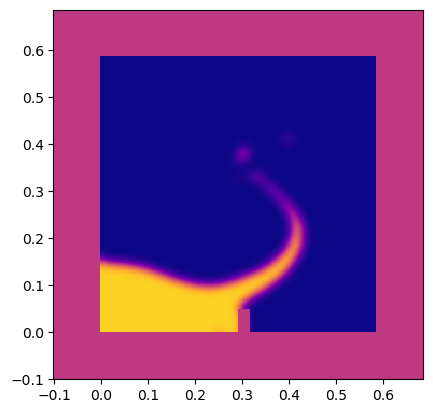

X_test_sROMs


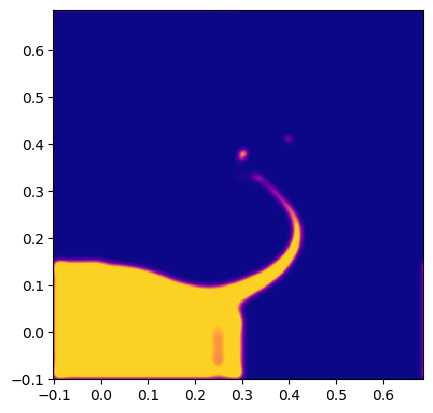

X_test_sROMs_nw


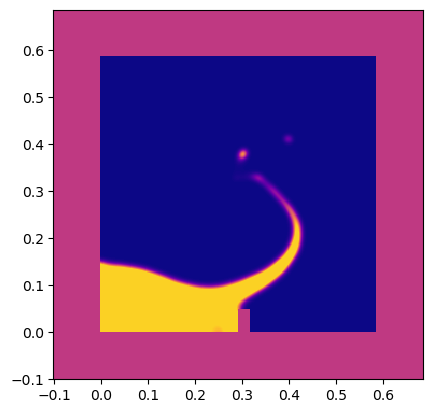

In [15]:
# validation
# optimize sharpening only
# list all databases and check
def imshow(ax, u):
    extent = (np.min(x)-dx/2, np.max(x)+dx/2, np.min(y)-dy/2, np.max(y)+dy/2)
    cs = ax.imshow(u.T, origin="lower", interpolation="nearest", extent=extent, cmap=cmap, vmin=0, vmax=1.1)
for name, snapshots in zip(["X_train", "X_train_s",
                  "X_test", "X_test_nw", 
                  "X_test_ROM", "X_test_ROM_nw", 
                  "X_test_sROM", "X_test_sROM_nw", 
                  "X_test_sROMs", "X_test_sROMs_nw"],
                    [X_train, X_train_s,
                  X_test, X_test_nw, 
                  X_test_ROM, X_test_ROM_nw, 
                  X_test_sROM, X_test_sROM_nw, 
                  X_test_sROMs, X_test_sROMs_nw]):
    print(name)
    fig, ax = plt.subplots()
    imshow(ax, snapshots[:, j].reshape(shape))
    plt.show()